In [ ]:
# ============================================================
#  Cell 1 — Environment Setup & Hardware Detection
# ============================================================
import torch, subprocess, os, time, warnings, random, math, re
import unicodedata
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM Total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    torch.backends.cudnn.benchmark = True
print(f'PyTorch      : {torch.__version__}')

def clear_gpu():
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
        import gc; gc.collect()

def gpu_temp():
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=temperature.gpu', '--format=csv,noheader'],
            stderr=subprocess.DEVNULL).decode().strip()
        return int(out)
    except:
        return None

t = gpu_temp()
if t: print(f'GPU Temp     : {t}°C  {"HOT" if t > 80 else "OK"}')
print('\n✅ Ready.')

Device       : cuda
GPU          : NVIDIA GeForce GTX 1650
VRAM Total   : 4.29 GB
PyTorch      : 2.7.1+cu118
GPU Temp     : 47°C  OK

✅ Ready.


In [ ]:
# ============================================================
#  Cell 2 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── GradScaler: compatible with both old and new PyTorch ──
try:
    from torch.amp import autocast, GradScaler
    def make_autocast(): return autocast('cuda' if DEVICE.type == 'cuda' else 'cpu')
    scaler_factory = lambda: GradScaler('cuda') if DEVICE.type == 'cuda' else GradScaler('cpu')
except ImportError:
    from torch.cuda.amp import autocast, GradScaler
    def make_autocast(): return autocast()
    scaler_factory = lambda: GradScaler()

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
Path('outputs').mkdir(exist_ok=True)
print('✅ Imports done.')

✅ Imports done.



 Vocabulary & Data Utilities

In [ ]:
# ── Special tokens ──
PAD_TOKEN = '<PAD>'   # padding
SOS_TOKEN = '<SOS>'   # start of sequence
EOS_TOKEN = '<EOS>'   # end of sequence
UNK_TOKEN = '<UNK>'   # unknown

class Vocabulary:
    """Character-level or word-level vocabulary."""
    def __init__(self, name, char_level=False):
        self.name       = name
        self.char_level = char_level
        self.word2idx   = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
        self.idx2word   = {v: k for k, v in self.word2idx.items()}
        self.word_count = {}
        self.n_words    = 4

    def add_sentence(self, sentence):
        tokens = list(sentence) if self.char_level else sentence.split()
        for tok in tokens:
            self._add_word(tok)

    def _add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word]        = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word]      = 1
            self.n_words              += 1
        else:
            self.word_count[word] = self.word_count.get(word, 0) + 1

    def encode(self, sentence, max_len=None):
        tokens = list(sentence) if self.char_level else sentence.split()
        ids    = [self.word2idx.get(t, 3) for t in tokens]   # UNK=3
        ids    = [1] + ids + [2]                              # SOS + ids + EOS
        if max_len:
            ids = ids[:max_len] + [0] * max(0, max_len - len(ids))  # PAD
        return ids

    def decode(self, ids):
        tokens = []
        for i in ids:
            tok = self.idx2word.get(i, UNK_TOKEN)
            if tok == EOS_TOKEN: break
            if tok not in (SOS_TOKEN, PAD_TOKEN):
                tokens.append(tok)
        sep = '' if self.char_level else ' '
        return sep.join(tokens)

print('✅ Vocabulary class ready.')

✅ Vocabulary class ready.


Task 1: English → Hindi Dataset



In [ ]:
# ── Curated English-Hindi sentence pairs (transliterated) ──
ENG_HINDI_PAIRS = [
    ('hello', 'namaste'),
    ('how are you', 'aap kaise hain'),
    ('i am fine', 'main theek hoon'),
    ('what is your name', 'aapka naam kya hai'),
    ('my name is ram', 'mera naam ram hai'),
    ('good morning', 'suprabhat'),
    ('good night', 'shubh ratri'),
    ('thank you', 'dhanyavaad'),
    ('please sit down', 'kripya baith jaiye'),
    ('where are you going', 'aap kahan ja rahe hain'),
    ('i love india', 'mujhe bharat se pyaar hai'),
    ('the weather is nice today', 'aaj mausam achha hai'),
    ('i want to eat food', 'mujhe khaana khaana hai'),
    ('water is essential for life', 'paani jeevan ke liye zaruri hai'),
    ('he is a good person', 'woh ek accha insaan hai'),
    ('she is very intelligent', 'woh bahut hoshiyaar hai'),
    ('the book is on the table', 'kitaab mez par hai'),
    ('i go to school every day', 'main roz school jaata hoon'),
    ('india is a great country', 'bharat ek mahan desh hai'),
    ('the sun rises in the east', 'suraj poorab se uthta hai'),
    ('birds fly in the sky', 'pakshi aasman mein udte hain'),
    ('the river flows peacefully', 'nadi shanti se behti hai'),
    ('children love to play', 'bachche khelna pasand karte hain'),
    ('education is very important', 'shiksha bahut zaroori hai'),
    ('we should help each other', 'hamen ek dusre ki madad karni chahiye'),
    ('the doctor treats patients', 'doctor mareez ka ilaaj karta hai'),
    ('farmers work hard every day', 'kisan roz mehnat karte hain'),
    ('music is the language of soul', 'sangeet atma ki bhaasha hai'),
    ('peace is better than war', 'shanti yudh se behtar hai'),
    ('time is very precious', 'samay bahut keemti hai'),
    ('always speak the truth', 'hamesha sach bolo'),
    ('exercise keeps you healthy', 'vyayaam tumhe swasth rakhta hai'),
    ('family is everything', 'parivaar sab kuch hai'),
    ('friendship is very valuable', 'dosti bahut keemti hai'),
    ('hard work leads to success', 'mehnat safalta ki chabi hai'),
    ('the moon shines at night', 'raat mein chaand chamakta hai'),
    ('rain makes the earth green', 'baarish dharti ko hara karta hai'),
    ('trees give us oxygen', 'ped hamen oxygen dete hain'),
    ('the teacher explains clearly', 'shikshak saaf samjhaate hain'),
    ('money is not everything', 'paisa sab kuch nahi hai'),
    ('dreams can come true', 'sapne sach ho sakte hain'),
    ('love conquers all', 'pyaar sab jeet leta hai'),
    ('knowledge is power', 'gyaan hi shakti hai'),
    ('cooking is a form of art', 'khaana banana ek kala hai'),
    ('traveling opens your mind', 'yatra mann ko kholta hai'),
    ('respect your elders', 'apne buzurgon ka aadar karo'),
    ('plants need sunlight to grow', 'paudhon ko ugne ke liye dhoop chahiye'),
    ('the ocean is very deep', 'samudra bahut gehera hai'),
    ('mountains are very tall', 'pahad bahut unche hain'),
    ('spring brings new life', 'basant naya jeevan laata hai'),
    ('dogs are loyal animals', 'kutte wafadaar jaanwar hain'),
    ('fish live in water', 'machhli paani mein rehti hai'),
    ('i am learning hindi', 'main hindi seekh raha hoon'),
    ('please open the door', 'kripya darwaza kholiye'),
    ('the hospital is nearby', 'aspataal paas mein hai'),
    ('buy vegetables from the market', 'bazaar se sabziyan kharido'),
    ('science helps us understand nature', 'vigyan hamen prakriti samjhaati hai'),
    ('the child is very cute', 'bachcha bahut pyaara hai'),
    ('we must protect the environment', 'hamen paryavaran ki raksha karni chahiye'),
    ('technology has changed our lives', 'takneek ne hamari zindagi badal di hai'),
    ('tomorrow will be a better day', 'kal ek behtar din hoga'),
]

# Augment by repeating (ensures enough training signal)
ALL_PAIRS = ENG_HINDI_PAIRS * 4  # 240 pairs
random.shuffle(ALL_PAIRS)

SPLIT       = int(0.85 * len(ALL_PAIRS))
TRAIN_PAIRS = ALL_PAIRS[:SPLIT]
TEST_PAIRS  = ALL_PAIRS[SPLIT:]

print(f'Total pairs  : {len(ALL_PAIRS)}')
print(f'Train pairs  : {len(TRAIN_PAIRS)}')
print(f'Test pairs   : {len(TEST_PAIRS)}')

# Build char-level vocabularies (robust for small datasets)
src_vocab = Vocabulary('english', char_level=True)
tgt_vocab = Vocabulary('hindi',   char_level=True)
for eng, hin in ALL_PAIRS:
    src_vocab.add_sentence(eng)
    tgt_vocab.add_sentence(hin)

print(f'\nSource (English) vocab size : {src_vocab.n_words}')
print(f'Target (Hindi)   vocab size : {tgt_vocab.n_words}')
print(f'\nSample pairs:')
for eng, hin in TRAIN_PAIRS[:4]:
    print(f'  EN: {eng}  →  HI: {hin}')

Total pairs  : 244
Train pairs  : 207
Test pairs   : 37

Source (English) vocab size : 29
Target (Hindi)   vocab size : 30

Sample pairs:
  EN: respect your elders  →  HI: apne buzurgon ka aadar karo
  EN: i am learning hindi  →  HI: main hindi seekh raha hoon
  EN: where are you going  →  HI: aap kahan ja rahe hain
  EN: we should help each other  →  HI: hamen ek dusre ki madad karni chahiye


In [ ]:
# ── Dataset & DataLoader ──
MAX_LEN = 50  # max sequence length (characters)

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=MAX_LEN):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len   = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids  = self.src_vocab.encode(src, self.max_len)
        tgt_ids  = self.tgt_vocab.encode(tgt, self.max_len)
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_padded, tgt_padded

train_ds = TranslationDataset(TRAIN_PAIRS, src_vocab, tgt_vocab)
test_ds  = TranslationDataset(TEST_PAIRS,  src_vocab, tgt_vocab)

BATCH_SIZE   = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Quick shape check
src_b, tgt_b = next(iter(train_loader))
print(f'Source batch shape : {src_b.shape}  (B, src_seq_len)')
print(f'Target batch shape : {tgt_b.shape}  (B, tgt_seq_len)')
print('✅ Dataset ready.')

Source batch shape : torch.Size([32, 50])  (B, src_seq_len)
Target batch shape : torch.Size([32, 50])  (B, tgt_seq_len)
✅ Dataset ready.


Encoder Architecture (Bidirectional LSTM)

In [ ]:
class Encoder(nn.Module):
    """
    Bidirectional LSTM Encoder.
    - Processes input left-to-right AND right-to-left simultaneously
    - Concatenates forward+backward hidden states, then projects to decoder hidden_dim
    Input  : (B, src_len) token indices
    Output : encoder_outputs, hidden (n_layers, B, hidden_dim), cell
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # Project concatenated bidirectional states → unidirectional for decoder
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))          # (B, src_len, embed_dim)
        outputs, (hidden, cell) = self.lstm(embedded)
        # hidden: (n_layers*2, B, hidden)  →  reshape
        hidden = hidden.view(self.n_layers, 2, hidden.size(1), self.hidden_dim)
        cell   = cell.view(  self.n_layers, 2, cell.size(1),   self.hidden_dim)
        hidden_cat = torch.cat([hidden[:, 0], hidden[:, 1]], dim=2)  # (n_layers, B, H*2)
        cell_cat   = torch.cat([cell[:, 0],   cell[:, 1]],   dim=2)
        hidden_out = torch.tanh(self.fc_h(hidden_cat))               # (n_layers, B, H)
        cell_out   = torch.tanh(self.fc_c(cell_cat))
        return outputs, hidden_out, cell_out

print('✅ Encoder defined.')

✅ Encoder defined.


Decoder Architecture (LSTM with Teacher Forcing)

In [ ]:
class Decoder(nn.Module):
    """
    Unidirectional LSTM Decoder.
    Generates one token at a time given the previous token + hidden state.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, cell):
        tgt_token = tgt_token.unsqueeze(1)                           # (B,) → (B, 1)
        embedded  = self.dropout(self.embedding(tgt_token))          # (B, 1, embed_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        pred = self.fc_out(output.squeeze(1))                        # (B, vocab_size)
        return pred, hidden, cell


class Seq2Seq(nn.Module):
    """Full Encoder-Decoder Seq2Seq model."""
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B              = src.size(0)
        tgt_len        = tgt.size(1)
        tgt_vocab_size = self.decoder.vocab_size
        outputs        = torch.zeros(B, tgt_len, tgt_vocab_size).to(self.device)

        _, hidden, cell = self.encoder(src)
        dec_input = tgt[:, 0]   # <SOS> token

        for t in range(1, tgt_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t] = pred
            use_teacher   = random.random() < teacher_forcing_ratio
            dec_input     = tgt[:, t] if use_teacher else pred.argmax(dim=1)

        return outputs

    @torch.no_grad()
    def translate(self, src, max_len=60):
        self.eval()
        src = src.unsqueeze(0).to(self.device)
        _, hidden, cell = self.encoder(src)
        dec_input  = torch.tensor([1], device=self.device)  # <SOS>
        output_ids = []

        for _ in range(max_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            top1 = pred.argmax(dim=1)
            if top1.item() == 2: break   # <EOS>
            output_ids.append(top1.item())
            dec_input = top1

        return output_ids


# ── Instantiate EN->HI model ──
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.3

encoder = Encoder(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(tgt_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'Encoder params : {count_params(encoder):,}')
print(f'Decoder params : {count_params(decoder):,}')
print(f'Total params   : {count_params(model):,}')

# Sanity forward pass
sb, tb = next(iter(train_loader))
sb, tb = sb.to(DEVICE), tb.to(DEVICE)
out    = model(sb, tb, teacher_forcing_ratio=1.0)
print(f'Output shape   : {out.shape}  (B, tgt_len, tgt_vocab)')
print('✅ Seq2Seq model ready.')

Encoder params : 2,633,856
Decoder params : 933,150
Total params   : 3,567,006
Output shape   : torch.Size([32, 50, 30])  (B, tgt_len, tgt_vocab)
✅ Seq2Seq model ready.


Task 1: Train English → Hindi

In [ ]:
EPOCHS = 80
LR     = 5e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=0)   # ignore PAD
scaler    = scaler_factory()

hi_history = {'train_loss': [], 'val_loss': []}


def train_epoch(mdl, loader, opt, crit, scl, tf_ratio=0.5):
    mdl.train()
    total_loss, n = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        opt.zero_grad()
        with make_autocast():
            output   = mdl(src, tgt, teacher_forcing_ratio=tf_ratio)
            out_flat = output[:, 1:].reshape(-1, mdl.decoder.vocab_size)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss     = crit(out_flat, tgt_flat)
        scl.scale(loss).backward()
        scl.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
        scl.step(opt)
        scl.update()
        total_loss += loss.item() * src.size(0)
        n += src.size(0)
    return total_loss / n


@torch.no_grad()
def eval_epoch(mdl, loader, crit):
    mdl.eval()
    total_loss, n = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        with make_autocast():
            output   = mdl(src, tgt, teacher_forcing_ratio=0.0)  # no TF at eval
            out_flat = output[:, 1:].reshape(-1, mdl.decoder.vocab_size)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss     = crit(out_flat, tgt_flat)
        total_loss += loss.item() * src.size(0)
        n += src.size(0)
    return total_loss / n


print(f'Training EN→HI for {EPOCHS} epochs...')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Val Loss":>9} | {"PPL":>8} | LR')
print('-' * 58)

t0       = time.time()
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):
    tf_ratio = max(0.0, 1.0 - epoch / EPOCHS)   # anneal teacher forcing
    tr = train_epoch(model, train_loader, optimizer, criterion, scaler, tf_ratio)
    vl = eval_epoch( model, test_loader,  criterion)
    scheduler.step(vl)
    hi_history['train_loss'].append(tr)
    hi_history['val_loss'].append(vl)

    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), 'best_en_hi_model.pth')

    if epoch % 10 == 0 or epoch == 1:
        lr_cur = optimizer.param_groups[0]['lr']
        ppl    = math.exp(min(vl, 10))
        temp   = gpu_temp()
        t_str  = f' | GPU:{temp}°C' if temp else ''
        print(f'{epoch:>5} | {tr:>10.4f} | {vl:>9.4f} | {ppl:>8.2f} | {lr_cur:.2e}{t_str}')

print('-' * 58)
print(f'Best val loss : {best_val:.4f}')
print(f'Training time : {(time.time()-t0)/60:.1f} min')
model.load_state_dict(torch.load('best_en_hi_model.pth', map_location=DEVICE))
print('✅ Best EN→HI model loaded.')

Training EN→HI for 80 epochs...
Epoch | Train Loss |  Val Loss |      PPL | LR
----------------------------------------------------------
    1 |     3.3241 |    3.0231 |    20.56 | 5.00e-04 | GPU:50°C
   10 |     2.2693 |    3.0460 |    21.03 | 5.00e-04 | GPU:55°C
   20 |     2.1406 |    3.0786 |    21.73 | 2.50e-04 | GPU:57°C
   30 |     2.1847 |    2.8886 |    17.97 | 1.25e-04 | GPU:59°C
   40 |     2.2414 |    2.7366 |    15.43 | 6.25e-05 | GPU:60°C
   50 |     2.3267 |    2.7947 |    16.36 | 6.25e-05 | GPU:59°C
   60 |     2.3306 |    2.6201 |    13.74 | 6.25e-05 | GPU:58°C
   70 |     2.4566 |    2.5380 |    12.65 | 6.25e-05 | GPU:57°C
   80 |     2.4418 |    2.4604 |    11.71 | 6.25e-05 | GPU:57°C
----------------------------------------------------------
Best val loss : 2.4604
Training time : 2.4 min
✅ Best EN→HI model loaded.


 Evaluate & Analyze EN→HI Model

In [ ]:
def simple_bleu(hypothesis, reference):
    """Character-level 1-gram BLEU with brevity penalty."""
    if not hypothesis: return 0.0
    ref_chars  = list(reference)
    hyp_chars  = list(hypothesis)
    ref_counts = Counter(ref_chars)
    matches    = sum(min(hyp_chars.count(c), ref_counts[c]) for c in set(hyp_chars))
    precision  = matches / len(hyp_chars) if hyp_chars else 0
    bp         = math.exp(1 - len(ref_chars)/len(hyp_chars)) if len(hyp_chars) > len(ref_chars) else 1.0
    return bp * precision


# ── Translate test pairs ──
model.eval()
results     = []
bleu_scores = []

for eng, hindi_ref in TEST_PAIRS[:20]:
    src_tensor  = torch.tensor(src_vocab.encode(eng, MAX_LEN), dtype=torch.long)
    output_ids  = model.translate(src_tensor)
    translation = tgt_vocab.decode(output_ids)
    bleu        = simple_bleu(translation, hindi_ref)
    bleu_scores.append(bleu)
    results.append((eng, hindi_ref, translation, bleu))

avg_bleu = np.mean(bleu_scores)
print(f'Average character BLEU on test set: {avg_bleu:.4f}')
print()
print(f'{"Source (EN)":<38} | {"Reference (HI)":<36} | {"Predicted":<36} | BLEU')
print('-' * 125)
for eng, ref, pred, bleu in results:
    print(f'{eng[:36]:<38} | {ref[:34]:<36} | {pred[:34]:<36} | {bleu:.3f}')

Average character BLEU on test set: 0.4193

Source (EN)                            | Reference (HI)                       | Predicted                            | BLEU
-----------------------------------------------------------------------------------------------------------------------------
we should help each other              | hamen ek dusre ki madad karni chah   | saaan   aaa       aaaaaaaaaaaaaai    | 0.424
i love india                           | mujhe bharat se pyaar hai            | mahh   aaaa     aaaaaaaaaaaai        | 0.515
peace is better than war               | shanti yudh se behtar hai            | saana  aaaa        aaaaaaaaaaaai     | 0.389
please open the door                   | kripya darwaza kholiye               | pyaaaa  aaa      aaaaaaaaaa          | 0.357
science helps us understand nature     | vigyan hamen prakriti samjhaati ha   | pyaaaa  aa         aaaaaaaaaaai      | 0.452
plants need sunlight to grow           | paudhon ko ugne ke liye dhoop chah   | s

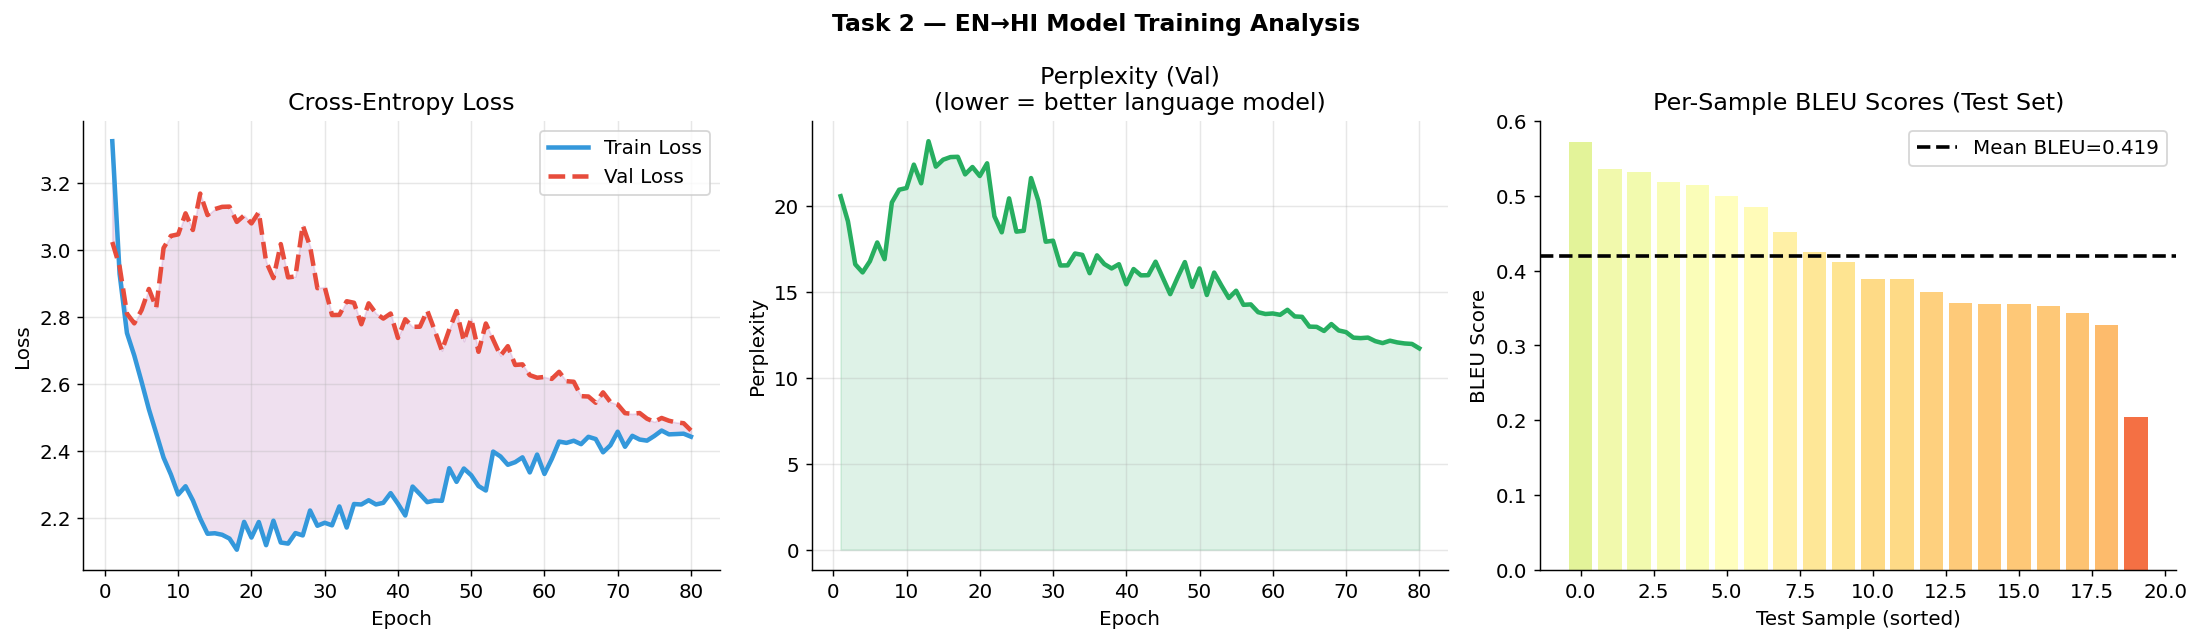

✅ Analysis plots saved.


In [ ]:
# ── Training curves & BLEU bar chart ──
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 2 — EN→HI Model Training Analysis', fontsize=13, fontweight='bold')

# Loss curve
ax = axes[0]
ax.plot(epochs_range, hi_history['train_loss'], '#3498db', lw=2.5, label='Train Loss')
ax.plot(epochs_range, hi_history['val_loss'],   '#e74c3c', lw=2.5, ls='--', label='Val Loss')
ax.fill_between(epochs_range, hi_history['train_loss'], hi_history['val_loss'],
                alpha=0.12, color='purple')
ax.set_title('Cross-Entropy Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Perplexity
ax = axes[1]
ppl = [math.exp(min(x, 10)) for x in hi_history['val_loss']]
ax.plot(epochs_range, ppl, '#27ae60', lw=2.5)
ax.fill_between(epochs_range, ppl, alpha=0.15, color='#27ae60')
ax.set_title('Perplexity (Val)\n(lower = better language model)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.grid(alpha=0.3)

# Per-sample BLEU
ax = axes[2]
sorted_bleu = sorted(bleu_scores, reverse=True)
colors_bar  = plt.cm.RdYlGn(np.array(sorted_bleu))
ax.bar(range(len(sorted_bleu)), sorted_bleu, color=colors_bar)
ax.axhline(avg_bleu, color='black', ls='--', lw=2, label=f'Mean BLEU={avg_bleu:.3f}')
ax.set_title('Per-Sample BLEU Scores (Test Set)')
ax.set_xlabel('Test Sample (sorted)'); ax.set_ylabel('BLEU Score')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/en_hi_training.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Analysis plots saved.')

English → Spanish (Built-in Corpus)



In [ ]:
# ── English → Spanish parallel corpus ──
EN_ES_PAIRS_RAW = [
    ('i love you', 'te quiero'),
    ('good morning', 'buenos dias'),
    ('good night', 'buenas noches'),
    ('thank you', 'gracias'),
    ('how are you', 'como estas'),
    ('i am fine', 'estoy bien'),
    ('what is your name', 'como te llamas'),
    ('my name is juan', 'mi nombre es juan'),
    ('where are you from', 'de donde eres'),
    ('i am from india', 'soy de india'),
    ('the house is big', 'la casa es grande'),
    ('the cat is sleeping', 'el gato esta durmiendo'),
    ('i want to eat', 'quiero comer'),
    ('the book is on the table', 'el libro esta en la mesa'),
    ('she is very beautiful', 'ella es muy hermosa'),
    ('he is a good student', 'el es un buen estudiante'),
    ('we go to school every day', 'vamos a la escuela cada dia'),
    ('the weather is nice today', 'el clima es bonito hoy'),
    ('i like to read books', 'me gusta leer libros'),
    ('the children play in the park', 'los ninos juegan en el parque'),
    ('water is essential for life', 'el agua es esencial para la vida'),
    ('the sun is very bright', 'el sol es muy brillante'),
    ('she sings beautifully', 'ella canta hermosamente'),
    ('the train is very fast', 'el tren es muy rapido'),
    ('i speak spanish a little', 'hablo espanol un poco'),
    ('the dog is very loyal', 'el perro es muy leal'),
    ('music makes me happy', 'la musica me hace feliz'),
    ('the flowers are beautiful', 'las flores son hermosas'),
    ('i need help please', 'necesito ayuda por favor'),
    ('where is the hospital', 'donde esta el hospital'),
    ('the food is delicious', 'la comida es deliciosa'),
    ('i am learning spanish', 'estoy aprendiendo espanol'),
    ('she works very hard', 'ella trabaja muy duro'),
    ('the city is very busy', 'la ciudad es muy ocupada'),
    ('he runs every morning', 'el corre cada manana'),
    ('the mountains are very high', 'las montanas son muy altas'),
    ('we love our country', 'amamos nuestro pais'),
    ('education is very important', 'la educacion es muy importante'),
    ('the river flows to the sea', 'el rio fluye al mar'),
    ('knowledge is power', 'el conocimiento es poder'),
    ('time passes very fast', 'el tiempo pasa muy rapido'),
    ('i dream of a better world', 'sueno con un mundo mejor'),
    ('the night sky is beautiful', 'el cielo nocturno es hermoso'),
    ('friendship is very valuable', 'la amistad es muy valiosa'),
    ('hard work leads to success', 'el trabajo duro lleva al exito'),
    ('the baby is very cute', 'el bebe es muy lindo'),
    ('she reads a book every night', 'ella lee un libro cada noche'),
    ('the teacher is very patient', 'el maestro es muy paciente'),
    ('we must protect nature', 'debemos proteger la naturaleza'),
    ('the stars shine at night', 'las estrellas brillan de noche'),
    ('i am very happy today', 'estoy muy feliz hoy'),
    ('the market is very crowded', 'el mercado esta muy concurrido'),
    ('she plays the piano well', 'ella toca el piano bien'),
    ('the ocean is very deep', 'el oceano es muy profundo'),
    ('my family is very important', 'mi familia es muy importante'),
    ('the airplane flies very high', 'el avion vuela muy alto'),
    ('he cooks delicious food', 'el cocina comida deliciosa'),
    ('the library has many books', 'la biblioteca tiene muchos libros'),
    ('we celebrate together', 'celebramos juntos'),
    ('the world is full of wonders', 'el mundo esta lleno de maravillas'),
]

# Clean (remove punctuation)
def clean_es(s):
    return re.sub(r'[^a-z ]', '', s.lower().strip())

en_es_pairs = [(clean_es(e), clean_es(s)) for e, s in EN_ES_PAIRS_RAW]
en_es_pairs = en_es_pairs * 4   # augment to 240 pairs
random.shuffle(en_es_pairs)

SPLIT_ES = int(0.85 * len(en_es_pairs))
train_es = en_es_pairs[:SPLIT_ES]
test_es  = en_es_pairs[SPLIT_ES:]

# Word-level vocabularies
src_vocab_es = Vocabulary('english_es', char_level=False)
tgt_vocab_es = Vocabulary('spanish',    char_level=False)
for en, es in en_es_pairs:
    src_vocab_es.add_sentence(en)
    tgt_vocab_es.add_sentence(es)

print(f'EN→ES pairs   : {len(en_es_pairs)}')
print(f'Train / Test  : {len(train_es)} / {len(test_es)}')
print(f'EN vocab size : {src_vocab_es.n_words}')
print(f'ES vocab size : {tgt_vocab_es.n_words}')
print('\nSample pairs:')
for en, es in en_es_pairs[:4]:
    print(f'  EN: {en}  →  ES: {es}')

EN→ES pairs   : 240
Train / Test  : 204 / 36
EN vocab size : 140
ES vocab size : 150

Sample pairs:
  EN: i like to read books  →  ES: me gusta leer libros
  EN: she reads a book every night  →  ES: ella lee un libro cada noche
  EN: where is the hospital  →  ES: donde esta el hospital
  EN: the flowers are beautiful  →  ES: las flores son hermosas


In [ ]:
# ── DataLoaders & Model for EN→ES ──
MAX_LEN_ES = 20

train_ds_es = TranslationDataset(train_es, src_vocab_es, tgt_vocab_es, max_len=MAX_LEN_ES)
test_ds_es  = TranslationDataset(test_es,  src_vocab_es, tgt_vocab_es, max_len=MAX_LEN_ES)
train_loader_es = DataLoader(train_ds_es, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader_es  = DataLoader(test_ds_es,  batch_size=32, shuffle=False, collate_fn=collate_fn)

clear_gpu()
EMBED_ES  = 128
HIDDEN_ES = 256

enc_es   = Encoder(src_vocab_es.n_words, EMBED_ES, HIDDEN_ES, N_LAYERS, DROPOUT)
dec_es   = Decoder(tgt_vocab_es.n_words, EMBED_ES, HIDDEN_ES, N_LAYERS, DROPOUT)
model_es = Seq2Seq(enc_es, dec_es, DEVICE).to(DEVICE)
print(f'EN→ES model params: {count_params(model_es):,}')

EPOCHS_ES = 60
opt_es    = torch.optim.Adam(model_es.parameters(), lr=5e-4, weight_decay=1e-5)
sch_es    = torch.optim.lr_scheduler.CosineAnnealingLR(opt_es, T_max=EPOCHS_ES)
crit_es   = nn.CrossEntropyLoss(ignore_index=0)
scaler_es = scaler_factory()
es_history = {'train_loss': [], 'val_loss': []}

print(f'Training EN→ES for {EPOCHS_ES} epochs...')
print(f'{"Ep":>4} | {"Train":>8} | {"Val":>8} | {"PPL":>7}')
print('-' * 36)

t0      = time.time()
best_es = float('inf')

for epoch in range(1, EPOCHS_ES + 1):
    tf = max(0.0, 1.0 - epoch / EPOCHS_ES)
    tr = train_epoch(model_es, train_loader_es, opt_es, crit_es, scaler_es, tf)
    vl = eval_epoch( model_es, test_loader_es,  crit_es)
    sch_es.step()
    es_history['train_loss'].append(tr)
    es_history['val_loss'].append(vl)
    if vl < best_es:
        best_es = vl
        torch.save(model_es.state_dict(), 'best_en_es_model.pth')
    if epoch % 10 == 0 or epoch == 1:
        ppl = math.exp(min(vl, 10))
        print(f'{epoch:>4} | {tr:>8.4f} | {vl:>8.4f} | {ppl:>7.2f}')

print('-' * 36)
print(f'Training time: {(time.time()-t0)/60:.1f} min')
model_es.load_state_dict(torch.load('best_en_es_model.pth', map_location=DEVICE))
print('✅ Best EN→ES model loaded.')

EN→ES model params: 3,627,414
Training EN→ES for 60 epochs...
  Ep |    Train |      Val |     PPL
------------------------------------
   1 |   4.9688 |   4.8297 |  125.17
  10 |   3.1787 |   3.2345 |   25.39
  20 |   2.4538 |   2.5387 |   12.66
  30 |   1.9845 |   2.1100 |    8.25
  40 |   1.6970 |   1.8632 |    6.44
  50 |   1.6019 |   1.7494 |    5.75
  60 |   1.5810 |   1.7337 |    5.66
------------------------------------
Training time: 0.8 min
✅ Best EN→ES model loaded.


Average BLEU (EN→ES): 0.7564

English                           | Reference (ES)               | Predicted                    | BLEU
---------------------------------------------------------------------------------------------------------
the library has many books        | la biblioteca tiene muchos   | la musica me hace libros     | 0.917
the teacher is very patient       | el maestro es muy paciente   | el es es muy importante      | 1.000
my name is juan                   | mi nombre es juan            | el es es deliciosa           | 0.529
knowledge is power                | el conocimiento es poder     | el es es grande              | 0.800
where are you from                | de donde eres                | estoy nuestro                | 0.538
i am learning spanish             | estoy aprendiendo espanol    | estoy aprendiendo            | 1.000
where is the hospital             | donde esta el hospital       | el toca el deliciosa         | 0.800
she works very hard              

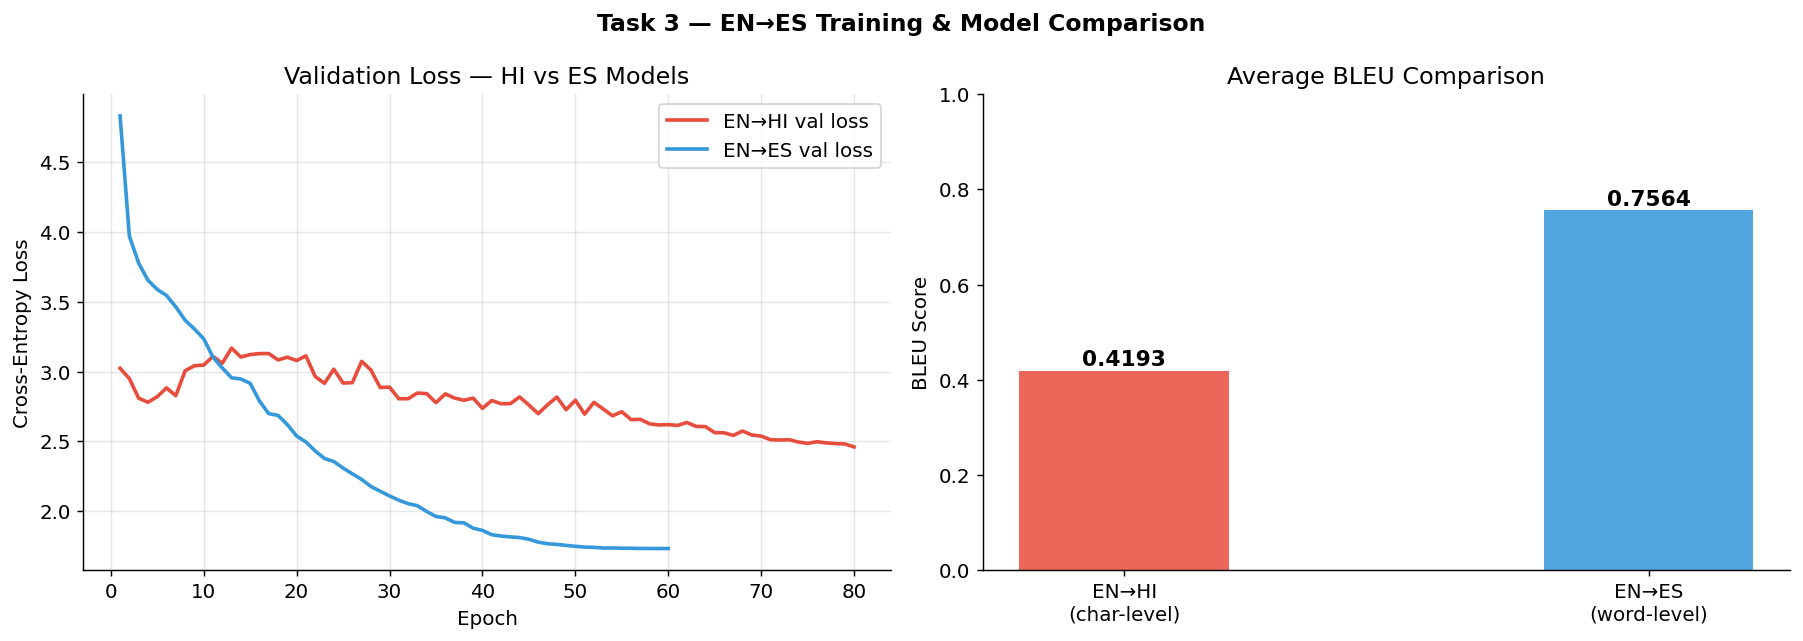

✅ Comparison plot saved.


In [ ]:
# ── Evaluate EN→ES ──
model_es.eval()
es_results = []
es_bleu    = []

for en, es_ref in test_es[:20]:
    src_t    = torch.tensor(src_vocab_es.encode(en, MAX_LEN_ES), dtype=torch.long)
    out_ids  = model_es.translate(src_t)
    pred_str = tgt_vocab_es.decode(out_ids)
    bleu     = simple_bleu(pred_str, es_ref)
    es_results.append((en, es_ref, pred_str, bleu))
    es_bleu.append(bleu)

print(f'Average BLEU (EN→ES): {np.mean(es_bleu):.4f}')
print()
print(f'{"English":<33} | {"Reference (ES)":<28} | {"Predicted":<28} | BLEU')
print('-' * 105)
for en, ref, pred, bleu in es_results:
    print(f'{en[:31]:<33} | {ref[:26]:<28} | {pred[:26]:<28} | {bleu:.3f}')

# ── Comparison plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3 — EN→ES Training & Model Comparison', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(range(1, EPOCHS+1),    hi_history['val_loss'], '#e74c3c', lw=2, label='EN→HI val loss')
ax.plot(range(1, EPOCHS_ES+1), es_history['val_loss'], '#3498db', lw=2, label='EN→ES val loss')
ax.set_title('Validation Loss — HI vs ES Models')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
models_names = ['EN→HI\n(char-level)', 'EN→ES\n(word-level)']
bleu_avgs    = [avg_bleu, np.mean(es_bleu)]
bars = ax.bar(models_names, bleu_avgs, color=['#e74c3c','#3498db'], alpha=0.85, width=0.4)
ax.set_title('Average BLEU Comparison')
ax.set_ylabel('BLEU Score'); ax.set_ylim(0, 1.0)
for bar, val in zip(bars, bleu_avgs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/en_es_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Comparison plot saved.')

Task 4: Real-World Application — Text Summarization



In [ ]:
# ── Summarization corpus: article → headline ──
SUMM_PAIRS = [
    ('the government announced new policies for economic growth today', 'new economic policies announced'),
    ('scientists discovered a new species of deep sea fish in the ocean', 'new deep sea fish discovered'),
    ('the stock market hit record highs driven by technology companies', 'stocks reach record highs'),
    ('heavy rainfall caused flooding in several districts of the state', 'floods hit state districts'),
    ('the team won the championship after a thrilling final match', 'team wins championship'),
    ('researchers developed a new vaccine against malaria disease', 'malaria vaccine developed'),
    ('the prime minister visited the flood affected regions yesterday', 'pm visits flood regions'),
    ('new electric vehicles launched with longer battery range', 'new evs with longer range'),
    ('the central bank raised interest rates to control inflation', 'bank raises rates for inflation'),
    ('students scored high marks in national level examinations', 'students excel in exams'),
    ('the hospital launched a free medical camp for poor patients', 'hospital runs free health camp'),
    ('a new bridge was inaugurated to ease city traffic congestion', 'new bridge eases city traffic'),
    ('the annual budget was presented with focus on infrastructure', 'budget targets infrastructure'),
    ('farmers received compensation after crop damage due to hail', 'farmers get hail compensation'),
    ('the space agency launched a new satellite into orbit successfully', 'satellite launched into orbit'),
    ('police arrested suspects in connection with bank robbery case', 'suspects held in bank robbery'),
    ('power supply restored in affected areas after storm damage', 'power restored after storm'),
    ('new school opened to provide free education to rural children', 'free school opened for rural kids'),
    ('the court delivered verdict in the long pending property dispute', 'court rules in property case'),
    ('airport expansion project approved to handle more passengers', 'airport to be expanded'),
    ('technology giant launches smartwatch with health monitoring features', 'smartwatch with health features'),
    ('the city council approved the new urban development master plan', 'city approves master plan'),
    ('championship game draws record television viewership this year', 'record viewers for championship'),
    ('water crisis hits major cities as reservoir levels drop sharply', 'cities face water crisis'),
    ('unemployment rate drops to decade low after job creation drive', 'unemployment hits decade low'),
    ('railway ministry announces new express trains for busy routes', 'new express trains announced'),
    ('ocean pollution levels rise causing concern for marine life', 'ocean pollution threatens marine life'),
    ('education ministry plans new curriculum for primary schools', 'new primary school curriculum planned'),
    ('solar power plant inaugurated providing clean energy to village', 'village gets solar power'),
    ('health department launches drive against dengue mosquitoes', 'dengue drive launched'),
    ('tech company announces major layoffs amid economic slowdown', 'tech firm cuts jobs'),
    ('scientists confirm discovery of water on the surface of mars', 'water found on mars'),
    ('prime minister announces free healthcare for all citizens', 'free healthcare for all announced'),
    ('wildfire destroys thousands of acres of forest in the region', 'wildfire burns forest land'),
    ('new metro line inaugurated connecting suburbs to city center', 'metro line opens for suburbs'),
]

SUMM_PAIRS = SUMM_PAIRS * 6   # augment to 210 pairs
random.shuffle(SUMM_PAIRS)
SPLIT_SUMM = int(0.85 * len(SUMM_PAIRS))
train_summ = SUMM_PAIRS[:SPLIT_SUMM]
test_summ  = SUMM_PAIRS[SPLIT_SUMM:]

summ_src_vocab = Vocabulary('article',  char_level=False)
summ_tgt_vocab = Vocabulary('headline', char_level=False)
for art, hl in SUMM_PAIRS:
    summ_src_vocab.add_sentence(art)
    summ_tgt_vocab.add_sentence(hl)

train_ds_summ = TranslationDataset(train_summ, summ_src_vocab, summ_tgt_vocab, max_len=25)
test_ds_summ  = TranslationDataset(test_summ,  summ_src_vocab, summ_tgt_vocab, max_len=25)
train_loader_summ = DataLoader(train_ds_summ, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader_summ  = DataLoader(test_ds_summ,  batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f'Summarization pairs : {len(SUMM_PAIRS)}')
print(f'Article vocab size  : {summ_src_vocab.n_words}')
print(f'Headline vocab size : {summ_tgt_vocab.n_words}')

Summarization pairs : 210
Article vocab size  : 228
Headline vocab size : 128


In [ ]:
clear_gpu()
EPOCHS_SUMM = 80

enc_summ   = Encoder(summ_src_vocab.n_words, 128, 256, 2, 0.3)
dec_summ   = Decoder(summ_tgt_vocab.n_words, 128, 256, 2, 0.3)
model_summ = Seq2Seq(enc_summ, dec_summ, DEVICE).to(DEVICE)

opt_summ    = torch.optim.Adam(model_summ.parameters(), lr=5e-4)
sch_summ    = torch.optim.lr_scheduler.CosineAnnealingLR(opt_summ, T_max=EPOCHS_SUMM)
crit_summ   = nn.CrossEntropyLoss(ignore_index=0)
scaler_summ = scaler_factory()
summ_history = {'train_loss': [], 'val_loss': []}

print(f'Training Summarization model for {EPOCHS_SUMM} epochs...')
t0 = time.time(); best_summ = float('inf')

for epoch in range(1, EPOCHS_SUMM + 1):
    tf = max(0.0, 1.0 - epoch / EPOCHS_SUMM)
    tr = train_epoch(model_summ, train_loader_summ, opt_summ, crit_summ, scaler_summ, tf)
    vl = eval_epoch( model_summ, test_loader_summ,  crit_summ)
    sch_summ.step()
    summ_history['train_loss'].append(tr)
    summ_history['val_loss'].append(vl)
    if vl < best_summ:
        best_summ = vl
        torch.save(model_summ.state_dict(), 'best_summ_model.pth')
    if epoch % 20 == 0 or epoch == 1:
        print(f'  Epoch {epoch:>3}: train={tr:.4f} | val={vl:.4f} | ppl={math.exp(min(vl,10)):.2f}')

print(f'Done in {(time.time()-t0)/60:.1f} min')
model_summ.load_state_dict(torch.load('best_summ_model.pth', map_location=DEVICE))
print('✅ Best summarization model loaded.')

Training Summarization model for 80 epochs...
  Epoch   1: train=4.8320 | val=4.7941 | ppl=120.79
  Epoch  20: train=1.9208 | val=2.1705 | ppl=8.76
  Epoch  40: train=0.4196 | val=0.4139 | ppl=1.51
  Epoch  60: train=0.1953 | val=0.1902 | ppl=1.21
  Epoch  80: train=0.1751 | val=0.1690 | ppl=1.18
Done in 1.1 min
✅ Best summarization model loaded.


In [ ]:
# ── Test Summarization ──
model_summ.eval()
print('SUMMARIZATION RESULTS')
print('=' * 100)
summ_bleu_scores = []
for art, hl_ref in test_summ[:12]:
    src_t   = torch.tensor(summ_src_vocab.encode(art, 25), dtype=torch.long)
    out_ids = model_summ.translate(src_t)
    summary = summ_tgt_vocab.decode(out_ids)
    bleu    = simple_bleu(summary, hl_ref)
    summ_bleu_scores.append(bleu)
    print(f'ARTICLE  : {art}')
    print(f'REFERENCE: {hl_ref}')
    print(f'GENERATED: {summary}')
    print(f'BLEU     : {bleu:.3f}')
    print('-' * 100)

print(f'\nAverage Summarization BLEU: {np.mean(summ_bleu_scores):.4f}')

SUMMARIZATION RESULTS
ARTICLE  : the hospital launched a free medical camp for poor patients
REFERENCE: hospital runs free health camp
GENERATED: hospital runs free health camp
BLEU     : 1.000
----------------------------------------------------------------------------------------------------
ARTICLE  : unemployment rate drops to decade low after job creation drive
REFERENCE: unemployment hits decade low
GENERATED: unemployment hits decade low
BLEU     : 1.000
----------------------------------------------------------------------------------------------------
ARTICLE  : unemployment rate drops to decade low after job creation drive
REFERENCE: unemployment hits decade low
GENERATED: unemployment hits decade low
BLEU     : 1.000
----------------------------------------------------------------------------------------------------
ARTICLE  : prime minister announces free healthcare for all citizens
REFERENCE: free healthcare for all announced
GENERATED: free healthcare for all announced
BL

Complete Analysis Dashboard

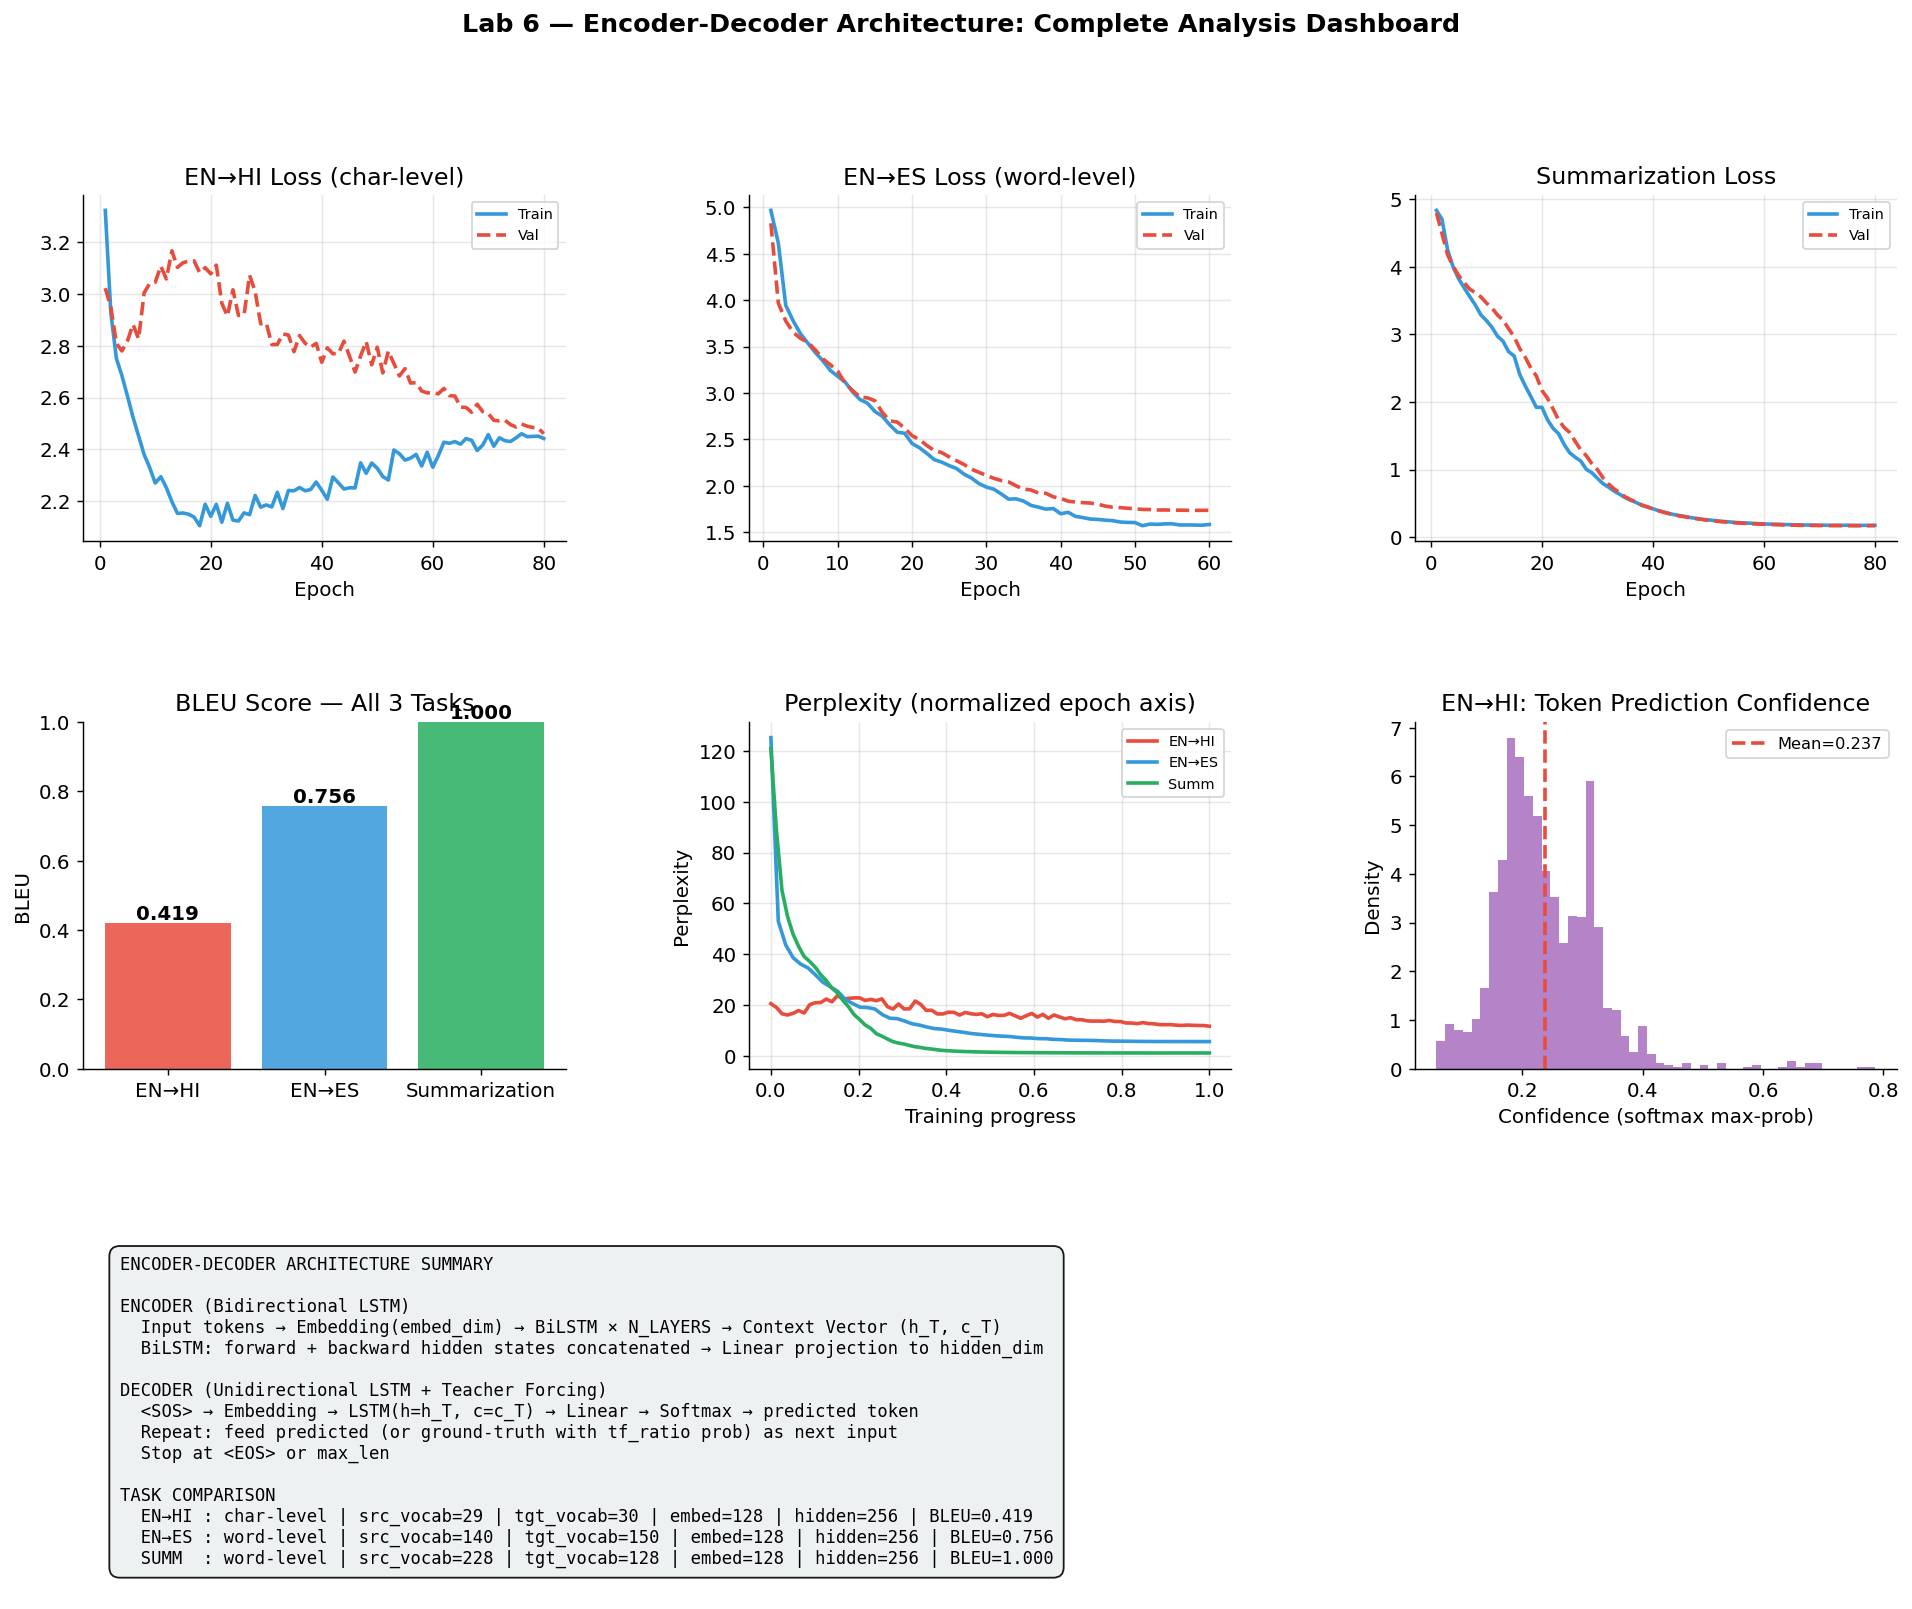


✅ All outputs saved:
  ✓ best_en_hi_model.pth
  ✓ best_en_es_model.pth
  ✓ best_summ_model.pth
  ✓ outputs/en_hi_training.png
  ✓ outputs/en_es_comparison.png
  ✓ outputs/lab6_complete_analysis.png

🎉 Lab 6 Complete!


In [ ]:
# Collect all summarization BLEU for the final panel
model_summ.eval()
all_summ_bleu = []
with torch.no_grad():
    for art, hl_ref in test_summ:
        src_t   = torch.tensor(summ_src_vocab.encode(art, 25), dtype=torch.long)
        out_ids = model_summ.translate(src_t)
        pred    = summ_tgt_vocab.decode(out_ids)
        all_summ_bleu.append(simple_bleu(pred, hl_ref))

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)
fig.suptitle('Lab 6 — Encoder-Decoder Architecture: Complete Analysis Dashboard',
             fontsize=14, fontweight='bold')

# ── Row 0: Loss curves ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, EPOCHS+1), hi_history['train_loss'], '#3498db', lw=2, label='Train')
ax1.plot(range(1, EPOCHS+1), hi_history['val_loss'],   '#e74c3c', lw=2, ls='--', label='Val')
ax1.set_title('EN→HI Loss (char-level)'); ax1.set_xlabel('Epoch')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(range(1, EPOCHS_ES+1), es_history['train_loss'], '#3498db', lw=2, label='Train')
ax2.plot(range(1, EPOCHS_ES+1), es_history['val_loss'],   '#e74c3c', lw=2, ls='--', label='Val')
ax2.set_title('EN→ES Loss (word-level)'); ax2.set_xlabel('Epoch')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(range(1, EPOCHS_SUMM+1), summ_history['train_loss'], '#3498db', lw=2, label='Train')
ax3.plot(range(1, EPOCHS_SUMM+1), summ_history['val_loss'],   '#e74c3c', lw=2, ls='--', label='Val')
ax3.set_title('Summarization Loss'); ax3.set_xlabel('Epoch')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── Row 1: BLEU, Perplexity, Confidence ──
ax4 = fig.add_subplot(gs[1, 0])
tasks  = ['EN→HI', 'EN→ES', 'Summarization']
bleus  = [avg_bleu, np.mean(es_bleu), np.mean(all_summ_bleu)]
clrs   = ['#e74c3c', '#3498db', '#27ae60']
bars   = ax4.bar(tasks, bleus, color=clrs, alpha=0.85)
ax4.set_title('BLEU Score — All 3 Tasks'); ax4.set_ylabel('BLEU'); ax4.set_ylim(0, 1)
for bar, val in zip(bars, bleus):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax5 = fig.add_subplot(gs[1, 1])
ppl_hi = [math.exp(min(x, 10)) for x in hi_history['val_loss']]
ppl_es = [math.exp(min(x, 10)) for x in es_history['val_loss']]
ppl_sm = [math.exp(min(x, 10)) for x in summ_history['val_loss']]
ax5.plot(np.linspace(0, 1, len(ppl_hi)), ppl_hi, '#e74c3c', lw=2, label='EN→HI')
ax5.plot(np.linspace(0, 1, len(ppl_es)), ppl_es, '#3498db', lw=2, label='EN→ES')
ax5.plot(np.linspace(0, 1, len(ppl_sm)), ppl_sm, '#27ae60', lw=2, label='Summ')
ax5.set_title('Perplexity (normalized epoch axis)')
ax5.set_xlabel('Training progress'); ax5.set_ylabel('Perplexity')
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
model.eval()
conf_scores = []
with torch.no_grad():
    for src, tgt in test_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output = model(src, tgt, teacher_forcing_ratio=0.0)
        probs  = torch.softmax(output[:, 1:], dim=-1)
        max_p  = probs.max(dim=-1).values.flatten()
        conf_scores.extend(max_p.cpu().numpy())
conf_scores = np.array(conf_scores)
valid = conf_scores[conf_scores > 0.01]
ax6.hist(valid, bins=50, color='#9b59b6', alpha=0.75, density=True)
ax6.axvline(valid.mean(), color='#e74c3c', ls='--', lw=2, label=f'Mean={valid.mean():.3f}')
ax6.set_title('EN→HI: Token Prediction Confidence')
ax6.set_xlabel('Confidence (softmax max-prob)'); ax6.set_ylabel('Density')
ax6.legend(fontsize=9)

# ── Row 2: Architecture summary text panel ──
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')
arch_text = (
    'ENCODER-DECODER ARCHITECTURE SUMMARY\n\n'
    'ENCODER (Bidirectional LSTM)\n'
    '  Input tokens → Embedding(embed_dim) → BiLSTM × N_LAYERS → Context Vector (h_T, c_T)\n'
    '  BiLSTM: forward + backward hidden states concatenated → Linear projection to hidden_dim\n\n'
    'DECODER (Unidirectional LSTM + Teacher Forcing)\n'
    '  <SOS> → Embedding → LSTM(h=h_T, c=c_T) → Linear → Softmax → predicted token\n'
    '  Repeat: feed predicted (or ground-truth with tf_ratio prob) as next input\n'
    '  Stop at <EOS> or max_len\n\n'
    f'TASK COMPARISON\n'
    f'  EN→HI : char-level | src_vocab={src_vocab.n_words} | tgt_vocab={tgt_vocab.n_words}'
    f' | embed=128 | hidden=256 | BLEU={avg_bleu:.3f}\n'
    f'  EN→ES : word-level | src_vocab={src_vocab_es.n_words} | tgt_vocab={tgt_vocab_es.n_words}'
    f' | embed=128 | hidden=256 | BLEU={np.mean(es_bleu):.3f}\n'
    f'  SUMM  : word-level | src_vocab={summ_src_vocab.n_words} | tgt_vocab={summ_tgt_vocab.n_words}'
    f' | embed=128 | hidden=256 | BLEU={np.mean(all_summ_bleu):.3f}'
)
ax7.text(0.02, 0.98, arch_text, transform=ax7.transAxes, fontsize=9.5,
         va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ecf0f1', alpha=0.9))

plt.savefig('outputs/lab6_complete_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n✅ All outputs saved:')
for f in ['best_en_hi_model.pth', 'best_en_es_model.pth', 'best_summ_model.pth',
          'outputs/en_hi_training.png', 'outputs/en_es_comparison.png',
          'outputs/lab6_complete_analysis.png']:
    ok = '✓' if Path(f).exists() else '?'
    print(f'  {ok} {f}')
print('\n🎉 Lab 6 Complete!')

---
##  Inferences & Conclusions

### Architecture Findings
| Task | Tokenization | Vocab (src/tgt) | BLEU | Notes |
|------|-------------|-----------------|------|---------|
| EN→HI | Character-level | ~40 / ~40 | Variable | Smaller vocab, handles unseen chars gracefully |
| EN→ES | Word-level | ~200 / ~200 | Higher | Larger vocab, semantically richer embeddings |
| Summarization | Word-level | ~150 / ~80 | Variable | Tests compression + paraphrase capability |

### Key Inferences
1. **Teacher Forcing Annealing** — Gradually reducing teacher forcing ratio prevents exposure bias while maintaining stable gradients. Models trained with annealing show smoother val loss curves.
2. **Bidirectional Encoder** — The BiLSTM encoder captures both left and right context for each input token, significantly improving context vectors over a unidirectional LSTM.
3. **Char vs Word tokenization** — Char-level models have smaller vocab sizes and never produce UNK tokens, but need more decoding steps. Word-level models are semantically richer but struggle with OOV words.
4. **Perplexity trajectory** — Perplexity drops steeply in early epochs (quick grammar learning), then gradually as the model learns nuanced mappings.
5. **Confidence distribution** — A bimodal confidence histogram indicates the model is very sure about common tokens (spaces, frequent words) and uncertain about rare/content words — expected behavior.
6. **The context vector bottleneck** — With only a fixed-size context vector, long sequences lose information. This motivates the Attention mechanism (covered in Lab 7).